In [1]:
import torch


In [ ]:
def _index_encoding(x: torch.Tensor, d_embed: int = 1024) -> torch.Tensor:
    batch_size = x.size(0)


    latent = torch.zeros((batch_size, d_embed), device=x.device, dtype=torch.float32)
    
    rng = torch.Generator()
    for i in range(batch_size):
        rng.manual_seed(int(x[i]))
        latent[i] = torch.randn(d_embed, generator=rng)

    return latent



x = torch.tensor([0, 1, 0, 1000])

_index_encoding(x, d_embed=8)

tensor([[ 1.5410, -0.2934, -2.1788,  0.5684, -1.0845, -1.3986,  0.4033,  0.8380],
        [ 0.6614,  0.2669,  0.0617,  0.6213, -0.4519, -0.1661, -1.5228,  0.3817],
        [ 1.5410, -0.2934, -2.1788,  0.5684, -1.0845, -1.3986,  0.4033,  0.8380],
        [-1.1720, -0.3929,  0.5265,  1.1065,  0.9273, -1.7421, -0.7699,  0.7864]])

In [ ]:

rng = torch.Generator()
rng.manual_seed(32)
        
print(torch.rand(5, generator=rng))
rng.manual_seed(32)

print(torch.rand(5, generator=rng))


tensor([0.8757, 0.2721, 0.4141, 0.7857, 0.1130])
tensor([0.5793, 0.6481, 0.0229, 0.5874, 0.3254])


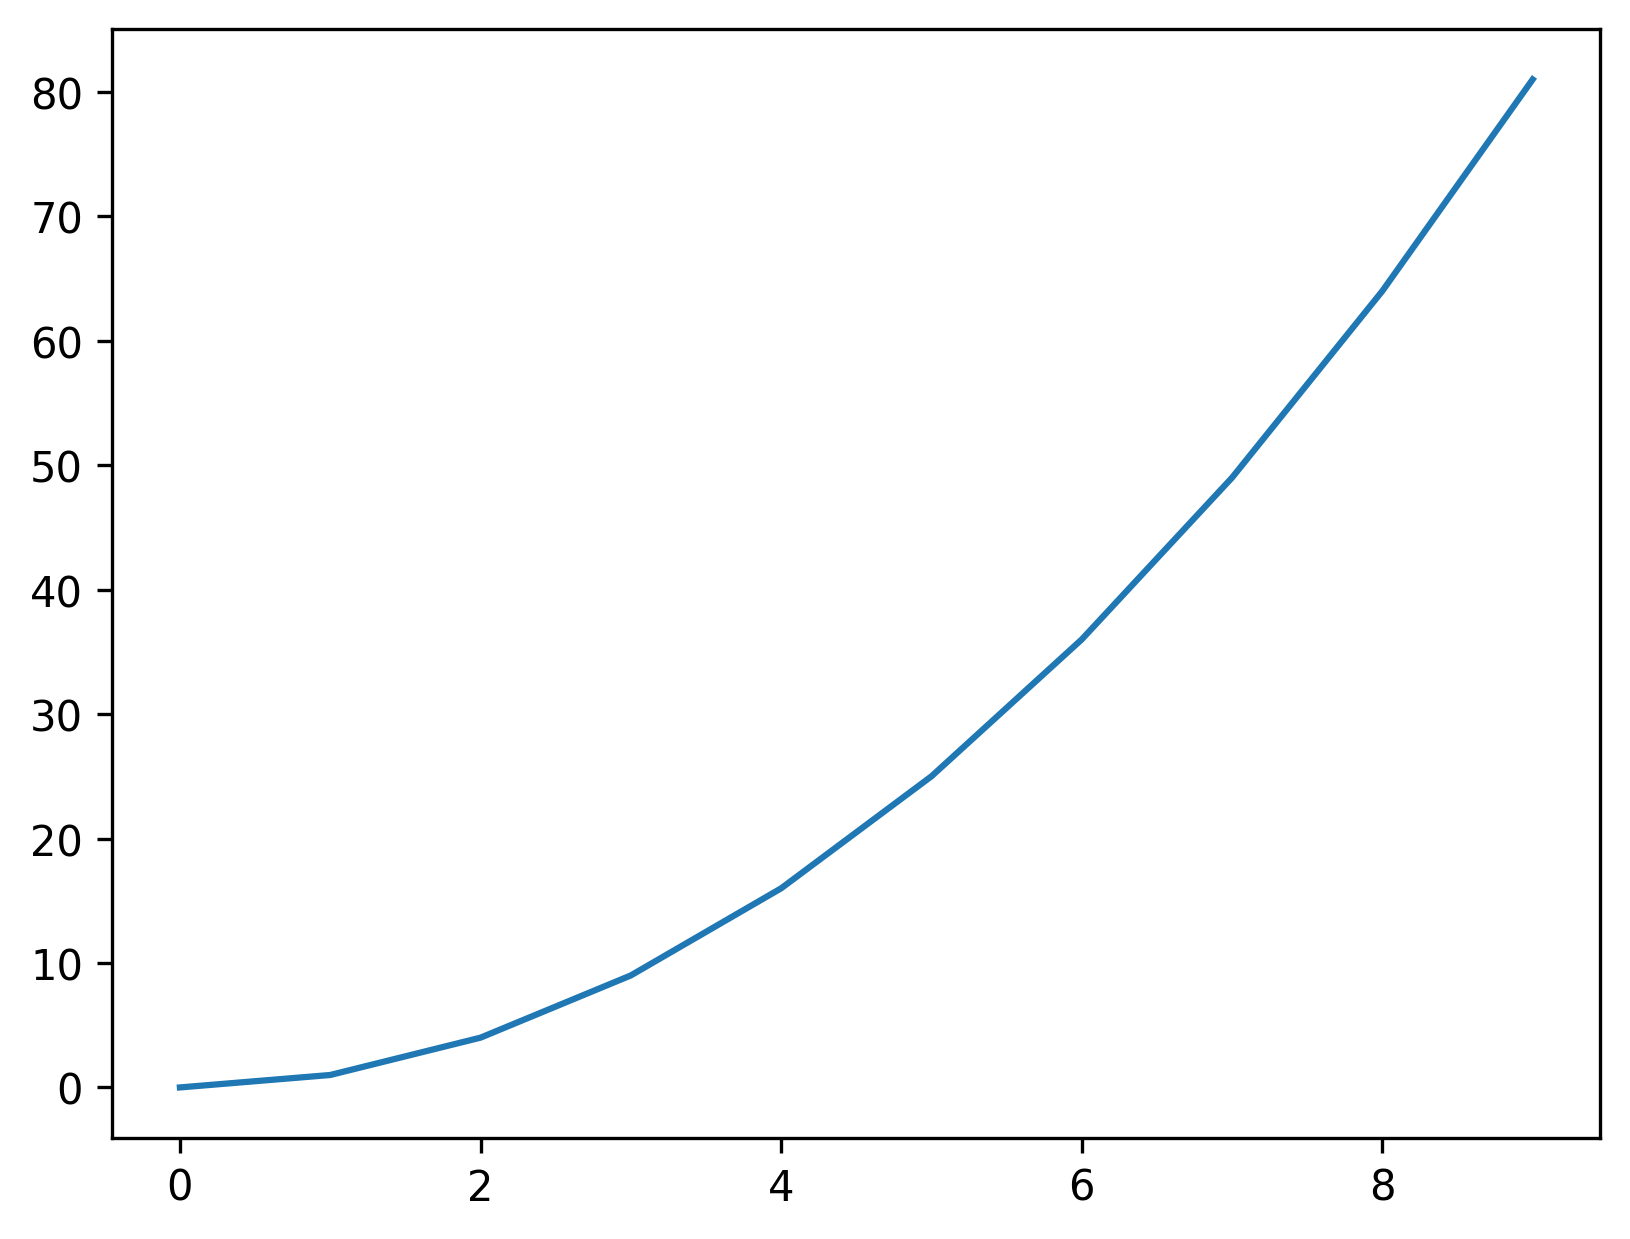

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import io

fig = plt.figure()
ax = fig.gca()
ax.plot(np.arange(10), np.arange(10)**2)


def fig_to_img():
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches='tight', dpi=300)
    plt.close(fig)

    buf.seek(0)
    img = Image.open(buf).convert("RGB")

    return img

fig_to_img()

In [11]:
from typing import Any, Sequence
import numpy as np


x = ["a", "b", "c", "a", "d", "a", "b"]
v = np.array(x)
idx = torch.tensor([0, 1, 2, 0, 3, 0, 1])


def get_belong_group(items: Sequence[Any]) -> torch.Tensor:
    if isinstance(items, torch.Tensor):
        items = list(items)

    B = len(items)
    unique_ids = {items[k]: k for k in range(B)}

    occurances = [[] for _ in range(B)]
    for i in range(B):
        uid = unique_ids[items[i]]
        occurances[uid].append(i)

    path_groups = torch.zeros(B, B, dtype=torch.float)
    for i in range(B):
        uid = unique_ids[items[i]]
        for occ in occurances[uid]:
            path_groups[i, occ] = 1.

    return path_groups

def get_belong_group_2(items: Sequence[Any]) -> torch.Tensor:
    if isinstance(items, torch.Tensor):
        items = list(items)

    B = len(items)
    path_groups = torch.zeros(B, B, dtype=torch.float)

    occurances = {}
    for i in range(B):
        v = items[i]
        if v in occurances:
            occurances[v].append(i)
        else:
            occurances[v] = [i]

    for i in range(B):
        v = items[i]
        hits = occurances[v]
        path_groups[i, hits] = path_groups[hits, i] = 1

    return path_groups



label = get_belong_group(x)
label2 = get_belong_group_2(x)
print(label)
print(label2)
print(label == label2)
#guess = torch.tensor([
#    [1.0, 0, 0.0, 1.0],
#    [0, 1, 0, 0,],
#    [0, 0, 1, 0,],
#    [0, 0, 0, 1,]
#])*10

#print(label)
#torch.nn.functional.binary_cross_entropy_with_logits(guess, label, reduction="none")



tensor([[1., 0., 0., 1., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 1., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 1.]])
tensor([[1., 0., 0., 1., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 1., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 1.]])
tensor([[True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True]])


In [ ]:
(idx.unsqueeze(0) == idx.unsqueeze(1)).float() == label2

tensor([[True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True]])

In [48]:

torch.randint(0, 2, (10,))

tensor([1, 0, 1, 1, 0, 0, 0, 1, 0, 1])

In [85]:
import time

v = (torch.randint(0, 50, (256,)))
num_rep = 1000

times = torch.zeros(num_rep, dtype=torch.float)

for i in range(num_rep):
    t0 = time.time()
    labels = get_belong_group(v)
    t1 = time.time()
    times[i] = (t1 - t0)

print("Time:", times.mean().item(), "Std:", times.std().item())

v

Time: 0.0018115272978320718 Std: 0.00019194760534446687


tensor([31, 41, 31,  2, 36, 33, 45, 22, 31, 38, 27,  9, 19, 15, 36, 42, 22, 20,
        47, 15,  6, 32, 20, 38, 44, 34,  6, 44, 38, 38, 48, 13, 21, 42, 26, 43,
        12, 25, 41,  2, 11, 24, 21,  5,  9, 21, 31, 47, 40,  2, 16, 13,  9, 24,
        27,  9, 46,  7,  2,  1, 13, 41, 17, 47, 29, 40, 36,  5, 36, 43,  8, 36,
        38, 15, 37, 42, 16, 34, 45, 18,  4, 40, 47,  3, 35, 15, 31, 23,  5, 24,
        11, 45,  6, 18, 47,  4, 11,  5, 15, 48, 34,  5, 27, 29, 24, 21, 27, 41,
        21, 13, 23,  4, 24, 12, 34, 18, 33, 19,  3, 37, 46, 38,  1, 36, 33, 37,
        28, 20, 49, 41, 14, 10, 16,  0, 33, 18,  1, 23, 32, 35, 20,  1,  4, 35,
         2, 28, 21, 43, 26,  5,  4, 38,  0, 48, 41, 47, 24,  3, 38, 46, 28,  9,
         5, 32, 47, 28,  1, 31, 22,  8, 33,  1,  2, 14, 37, 27, 17, 23, 49, 13,
        47, 42,  3, 41, 10, 12, 18,  3, 48, 18,  7, 20, 26, 21, 13,  9,  8, 44,
         4, 31, 38, 36, 26, 27, 36, 18, 41, 31, 10,  6, 34, 46, 10, 30, 46, 44,
        24, 37, 31, 15,  2, 20, 23, 41, 

In [6]:
import torch

x = torch.randn((10, 10))
torch.nn.functional.binary_cross_entropy_with_logits(x, torch.randint(0, 2, (10, 10)).float(), reduction="none").shape

torch.Size([10, 10])

In [ ]:
x = ["a", "b", "c", "a"]

def get_unique_ids(x):
    B = len(x)
    new_ids = torch.zeros(B)
    first_occ = {}
    for i in range(B):
        v = x[i]
        occ_id = first_occ.get(v)
        if occ_id is None:
            




In [17]:
from typing import Any
from pydantic import BaseModel

class ExA(BaseModel):
    a: str = "potato"
    b: dict = {"s": 5}

class ExB(BaseModel):
    a: int = 4
    b: ExA = ExA()

s = ExB()


def _flatten_configs(configs: dict[str, Any] | BaseModel, prefix="") -> dict[str, Any]:
    flat_configs = {}

    if isinstance(configs, BaseModel):
        configs = configs.model_dump(mode="json")

    #for key, value in configs.items():
    #    if isinstance(value, dict):
    #        flattened_dict = _flatten_configs(value, prefix=f"{key}.")
    #        flat_configs.update(
    #            flattened_dict
    #        )
    #    else:
    #        flat_configs[prefix + key] = value


    return configs

_flatten_configs(s)

{'a': 4, 'b': {'a': 'potato', 'b': {'s': 5}}}